# Employee Attrition Prediction
### Major Project — Individual Assignment | HR / People Analytics

**Goal:** Build a classification model that predicts whether an employee is likely to leave the
organization (`Attrition`), identify the key drivers of attrition, and translate the findings into
practical retention recommendations for HR.

**Dataset:** IBM HR Analytics Employee Attrition Dataset (Kaggle)
[https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

**Workflow:** Data → Statistics → EDA → Preprocessing → Feature Engineering → Modeling → Evaluation → Insights → Recommendations

---
### How to run this in Google Colab
1. Upload `WA_Fn-UseC_-HR-Employee-Attrition.csv` (in the same folder as this notebook) to your Colab session
   — either drag it into the Colab **Files** pane, or run the cell below and use the file picker.
2. Run all cells in order (`Runtime → Run all`).


In [1]:
# If running in Google Colab, uncomment the block below to upload the dataset manually
# from google.colab import files
# uploaded = files.upload()  # choose WA_Fn-UseC_-HR-Employee-Attrition.csv


## 0. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## A. Data Understanding

We load the dataset, look at its shape, data types, missing values, duplicates, and get a first
feel for the business meaning of each column.

In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape:", df.shape)
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

**Business meaning of key columns**

| Column | Meaning |
|---|---|
| `Attrition` | Target variable — did the employee leave? (Yes/No) |
| `Age`, `Gender`, `MaritalStatus` | Demographics |
| `Department`, `JobRole`, `JobLevel` | Where the employee sits in the org |
| `MonthlyIncome`, `PercentSalaryHike`, `StockOptionLevel` | Compensation |
| `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance` | Employee sentiment (1=Low ... 4=Very High) |
| `OverTime` | Whether the employee regularly works overtime |
| `DistanceFromHome` | Commute distance in miles/km |
| `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager`, `TotalWorkingYears` | Tenure-related |
| `PerformanceRating` | Manager-assigned performance score |
| `NumCompaniesWorked`, `TrainingTimesLastYear` | Career history / development |


In [5]:
# Numerical vs categorical variables
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):\n{numerical_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")


Numerical columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


/tmp/ipykernel_180/4192330311.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [6]:
# Missing values
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
missing[missing > 0]


Total missing values: 0


Series([], dtype: int64)

In [7]:
# Duplicate records
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [8]:
# Columns with a single constant value (no predictive power) and unique-value counts
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns (candidates to drop):", constant_cols)

df[constant_cols].describe() if constant_cols else "None"


Constant columns (candidates to drop): ['EmployeeCount', 'Over18', 'StandardHours']


,EmployeeCount,StandardHours
count,1470.0,1470.0
mean,1.0,80.0
std,0.0,0.0
min,1.0,80.0
25%,1.0,80.0
50%,1.0,80.0
75%,1.0,80.0
max,1.0,80.0


In [9]:
# Unique value counts for categorical columns
for c in categorical_cols:
    print(f"\n{c} ({df[c].nunique()} unique):")
    print(df[c].value_counts())



Attrition (2 unique):
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel (3 unique):
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department (3 unique):
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField (6 unique):
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender (2 unique):
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole (9 unique):
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52

**Observations:**
- The dataset has **1,470 employees and 35 columns**, with **no missing values and no duplicate rows** —
  this is a clean, well-curated dataset.
- `EmployeeCount`, `Over18`, and `StandardHours` are constant across all rows (no variance), so they
  carry no predictive information and will be dropped.
- `EmployeeNumber` is a unique identifier, not a feature, and will also be dropped.
- The target `Attrition` is a binary Yes/No column that we will encode as 1/0.


## B. Statistical Analysis

Descriptive statistics for the numerical variables, plus a look at distribution shape and correlation.

In [10]:
desc = df[numerical_cols].describe().T
desc["variance"] = df[numerical_cols].var()
desc["IQR"] = desc["75%"] - desc["25%"]
desc["mode"] = df[numerical_cols].mode().iloc[0]
desc[["mean", "mode", "50%", "std", "variance", "min", "max", "25%", "75%", "IQR"]].round(2)


,mean,mode,50%,std,variance,min,max,25%,75%,IQR
Age,36.92,35.0,36.0,9.14,83.46,18.0,60.0,30.00,43.00,13.00
DailyRate,802.49,691.0,802.0,403.51,162819.59,102.0,1499.0,465.00,1157.00,692.00
DistanceFromHome,9.19,2.0,7.0,8.11,65.72,1.0,29.0,2.00,14.00,12.00
Education,2.91,3.0,3.0,1.02,1.05,1.0,5.0,2.00,4.00,2.00
EmployeeCount,1.00,1.0,1.0,0.00,0.00,1.0,1.0,1.00,1.00,0.00
EmployeeNumber,1024.87,1.0,1020.5,602.02,362433.30,1.0,2068.0,491.25,1555.75,1064.50
EnvironmentSatisfaction,2.72,3.0,3.0,1.09,1.19,1.0,4.0,2.00,4.00,2.00
HourlyRate,65.89,66.0,66.0,20.33,413.29,30.0,100.0,48.00,83.75,35.75
JobInvolvement,2.73,3.0,3.0,0.71,0.51,1.0,4.0,2.00,3.00,1.00
JobLevel,2.06,1.0,2.0,1.11,1.23,1.0,5.0,1.00,3.00,2.00


In [11]:
# Skewness / distribution shape for a few business-critical variables
for col in ["MonthlyIncome", "YearsAtCompany", "Age", "DistanceFromHome", "TotalWorkingYears"]:
    print(f"{col}: skew={df[col].skew():.2f}, kurtosis={df[col].kurt():.2f}")


MonthlyIncome: skew=1.37, kurtosis=1.01
YearsAtCompany: skew=1.76, kurtosis=3.94
Age: skew=0.41, kurtosis=-0.40
DistanceFromHome: skew=0.96, kurtosis=-0.22
TotalWorkingYears: skew=1.12, kurtosis=0.92


**Business reading of the statistics:**
- `MonthlyIncome` is **right-skewed** (skew ≈ 1.4): most employees earn in a moderate band, but a
  smaller group of senior/high-level employees pulls the average up — median income is a more honest
  "typical" figure than the mean here.
- `YearsAtCompany` and `TotalWorkingYears` are also right-skewed, reflecting that most of the workforce
  is relatively early-career/early-tenure, with a long tail of veteran employees.
- `Age` is fairly symmetric (skew close to 0), centered around the mid-30s, consistent with a typical
  corporate workforce.
- The wide IQR on `MonthlyIncome` relative to `Age`/`DistanceFromHome` signals **pay dispersion is a
  bigger differentiator between employees than demographics** — worth investigating as an attrition driver.


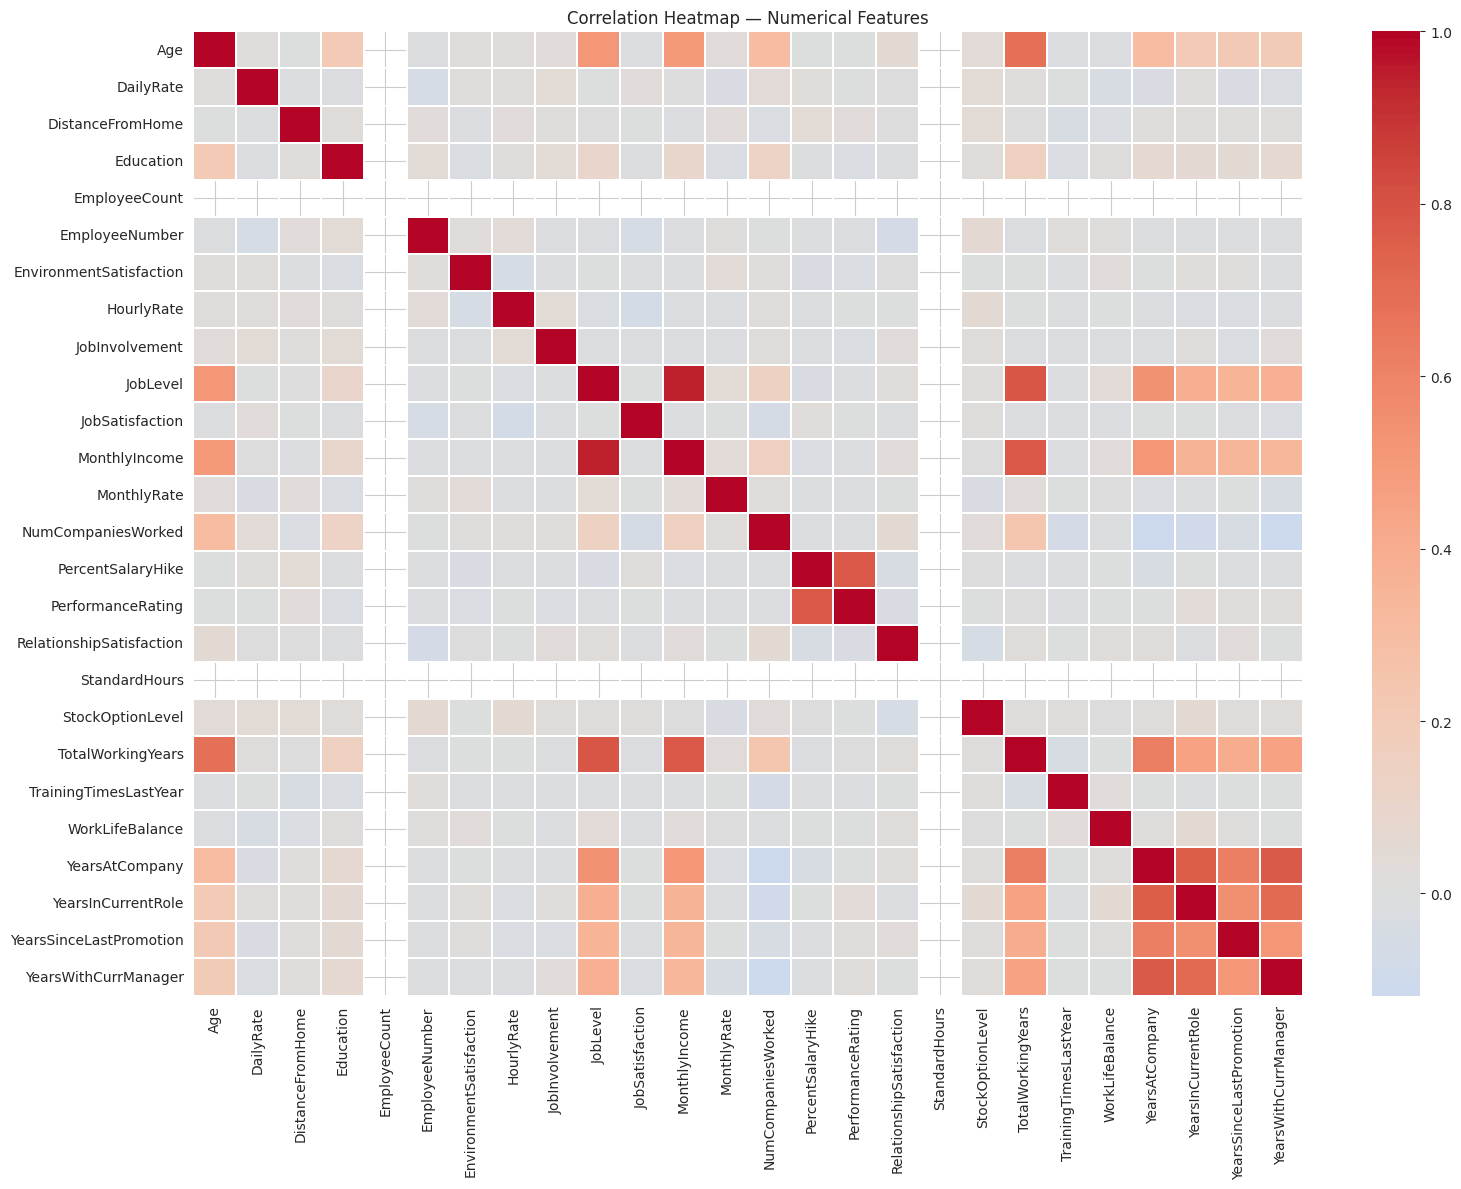

In [12]:
# Correlation matrix (numerical features) 
corr = df[numerical_cols].corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()


In [13]:
# Strongest pairwise correlations (excluding self-correlation)
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
corr_pairs.head(15)


MonthlyIncome            JobLevel                   0.950300
JobLevel                 TotalWorkingYears          0.782208
PercentSalaryHike        PerformanceRating          0.773550
TotalWorkingYears        MonthlyIncome              0.772893
YearsWithCurrManager     YearsAtCompany             0.769212
YearsInCurrentRole       YearsAtCompany             0.758754
YearsWithCurrManager     YearsInCurrentRole         0.714365
Age                      TotalWorkingYears          0.680381
TotalWorkingYears        YearsAtCompany             0.628133
YearsSinceLastPromotion  YearsAtCompany             0.618409
YearsInCurrentRole       YearsSinceLastPromotion    0.548056
YearsAtCompany           JobLevel                   0.534739
MonthlyIncome            YearsAtCompany             0.514285
YearsWithCurrManager     YearsSinceLastPromotion    0.510224
JobLevel                 Age                        0.509604
dtype: float64

**Correlation insights:** `JobLevel`, `MonthlyIncome`, and `TotalWorkingYears` are strongly
correlated with one another (as expected — more experienced, higher-level employees earn more).
`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, and `YearsSinceLastPromotion` also
move together, since they all capture tenure. This multicollinearity is useful to know for
Logistic Regression (coefficients can become unstable) but doesn't hurt tree-based models.


## C. Exploratory Data Analysis (EDA)

### C.1 Target variable distribution

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


/tmp/ipykernel_180/3196606827.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Attrition", palette=["#4C72B0", "#DD8452"])


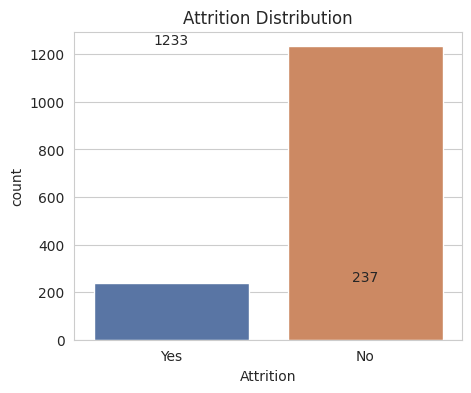

In [14]:
attr_counts = df["Attrition"].value_counts()
attr_pct = df["Attrition"].value_counts(normalize=True) * 100
print(attr_counts)
print(attr_pct.round(1))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Attrition", palette=["#4C72B0", "#DD8452"])
plt.title("Attrition Distribution")
for i, v in enumerate(attr_counts):
    plt.text(i, v + 10, str(v), ha="center")
plt.show()


Attrition is **imbalanced**: only about **16% of employees left** (237 of 1,470) vs. 84% who stayed.
This matters a lot for modeling — plain accuracy will be misleading, and we must pay close attention
to **Recall/F1 on the "Yes" class**, and consider class-imbalance handling.

### C.2 Univariate analysis — numerical variables

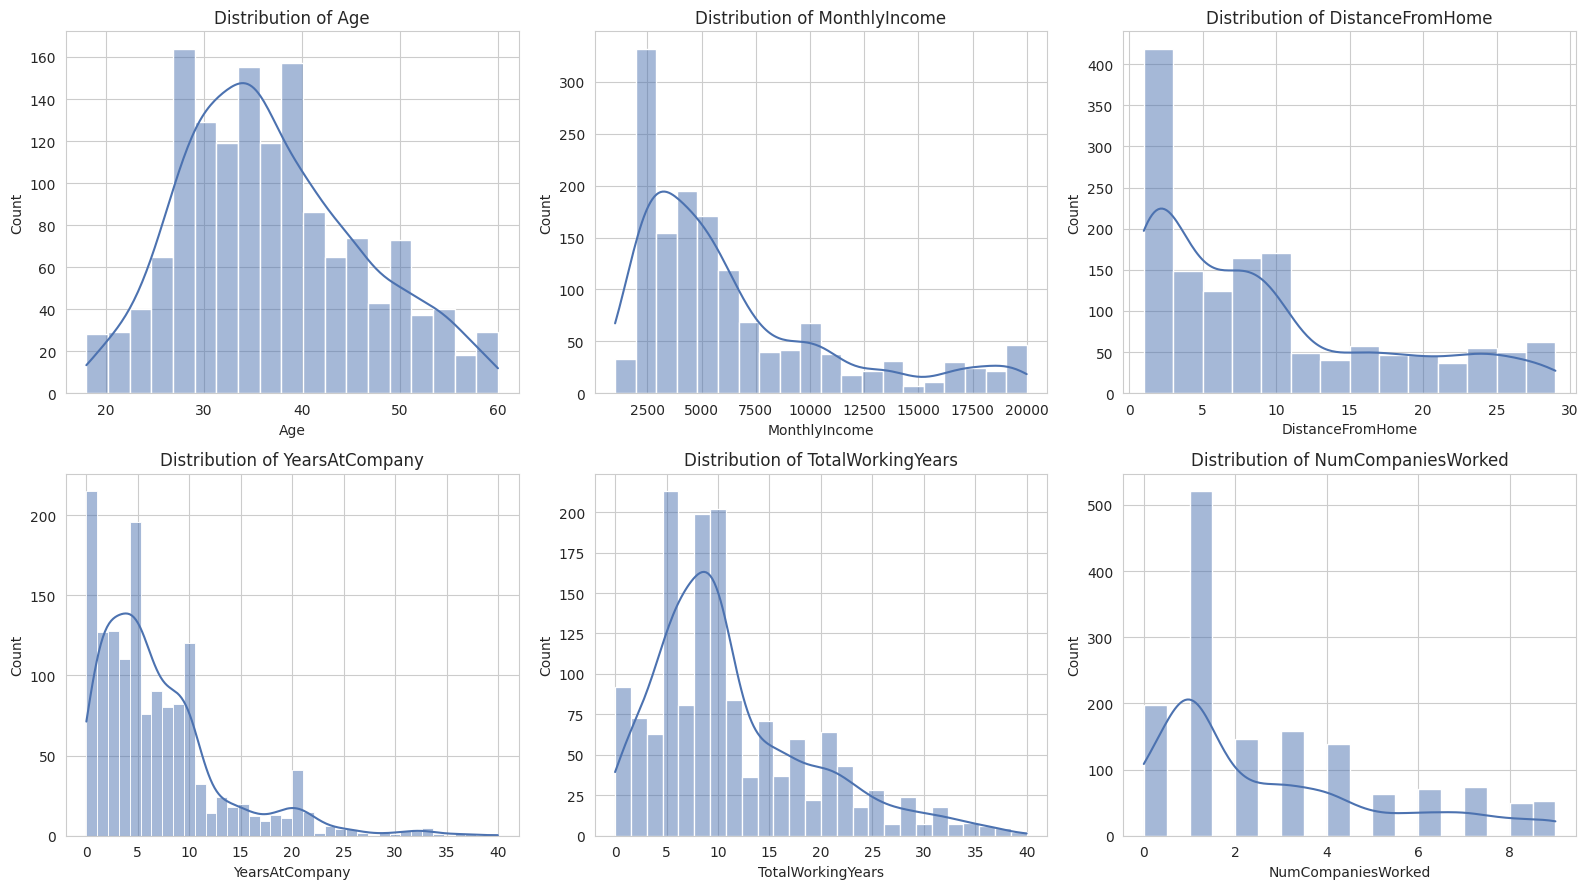

In [15]:
num_features_to_plot = ["Age", "MonthlyIncome", "DistanceFromHome", "YearsAtCompany",
                         "TotalWorkingYears", "NumCompaniesWorked"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_features_to_plot):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### C.3 Univariate analysis — categorical variables

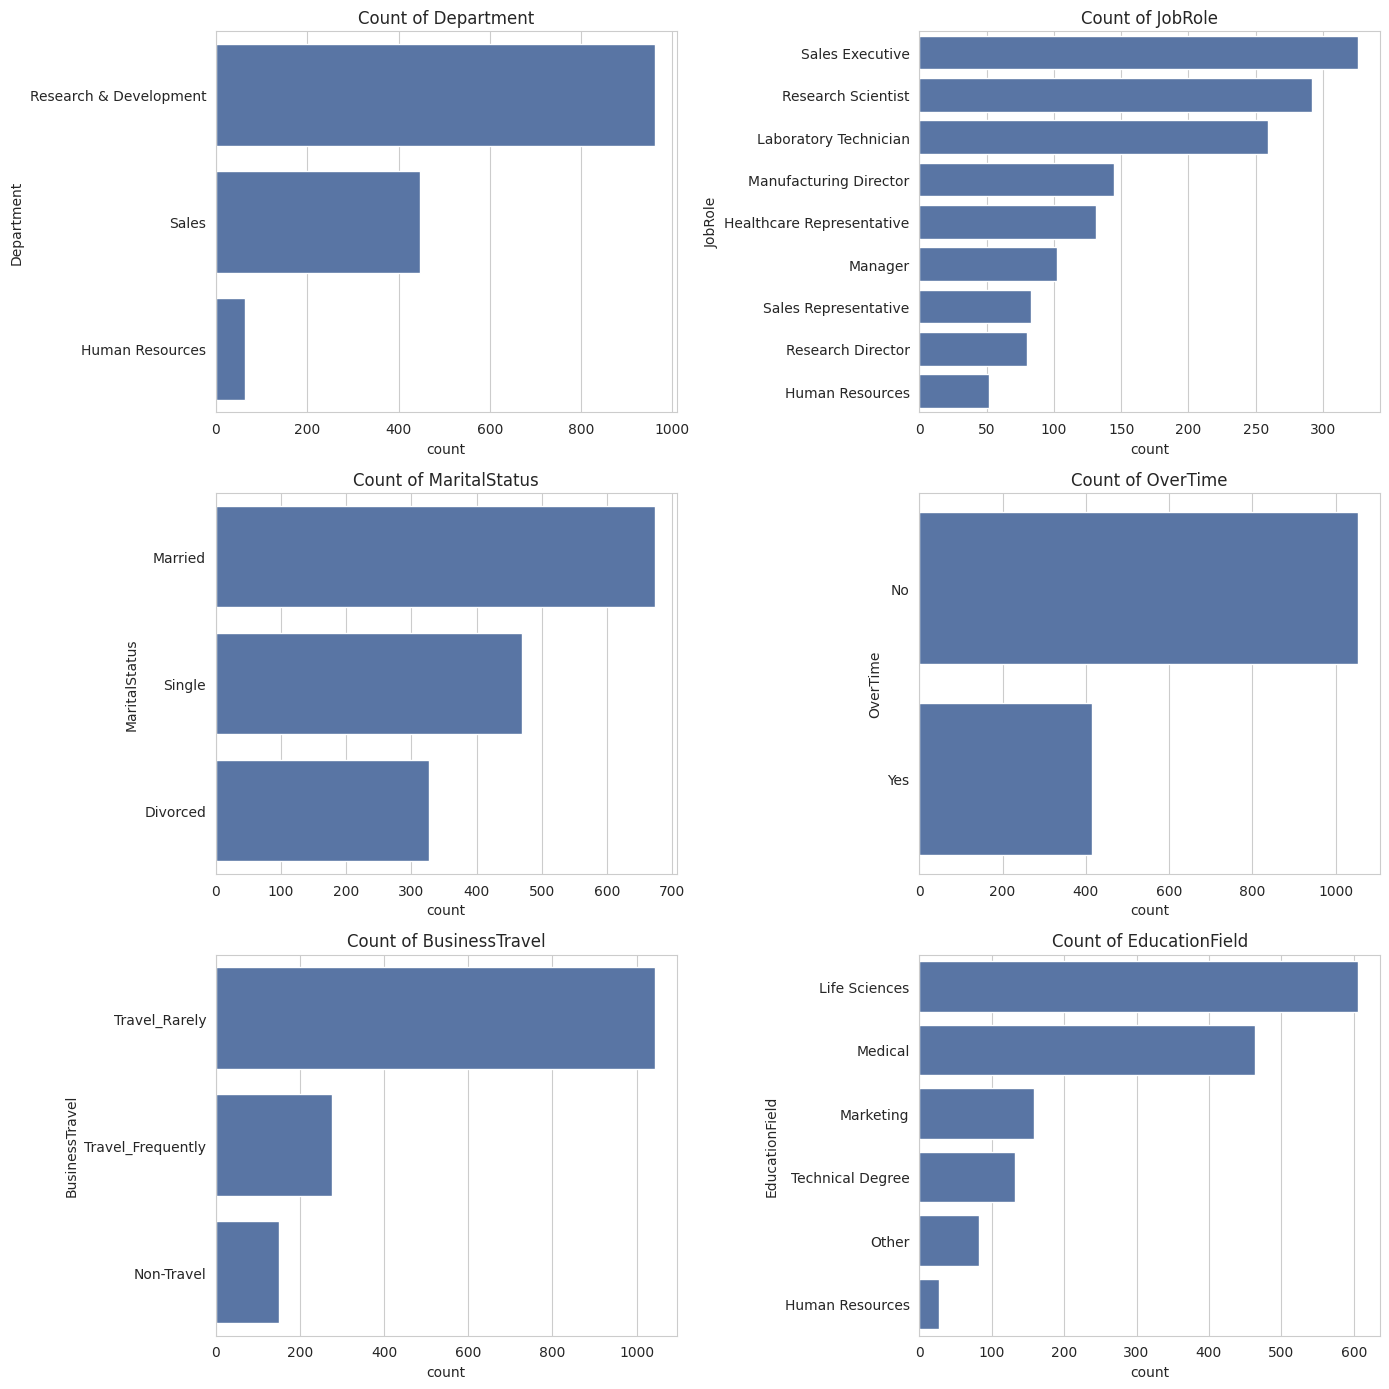

In [16]:
cat_features_to_plot = ["Department", "JobRole", "MaritalStatus", "OverTime",
                        "BusinessTravel", "EducationField"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flatten(), cat_features_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#4C72B0")
    ax.set_title(f"Count of {col}")
plt.tight_layout()
plt.show()


### C.4 Bivariate analysis — Attrition vs. key numerical drivers

/tmp/ipykernel_180/2891381445.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_180/2891381445.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_180/2891381445.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
/tmp/ipykernel_180/2891381445.py:3: FutureWarning: 

Passing `palette` without assigning `h

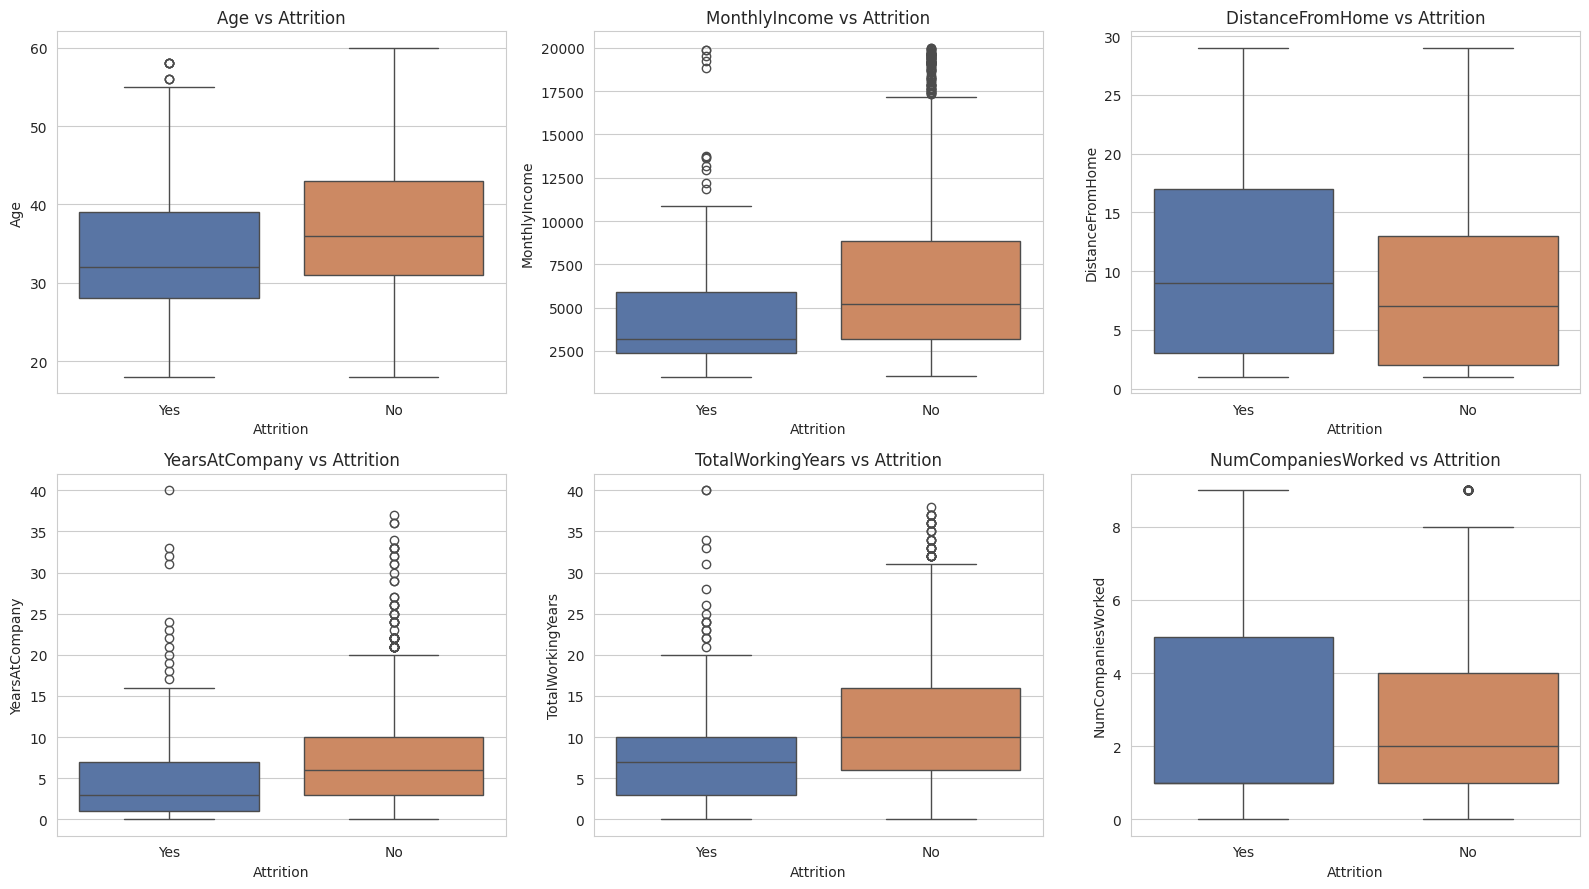

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), num_features_to_plot):
    sns.boxplot(data=df, x="Attrition", y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} vs Attrition")
plt.tight_layout()
plt.show()


In [18]:
df.groupby("Attrition")[num_features_to_plot].mean().round(1)


,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany,TotalWorkingYears,NumCompaniesWorked
Attrition,,,,,,
No,37.6,6832.7,8.9,7.4,11.9,2.6
Yes,33.6,4787.1,10.6,5.1,8.2,2.9


### C.5 Bivariate analysis — Attrition vs. key categorical drivers

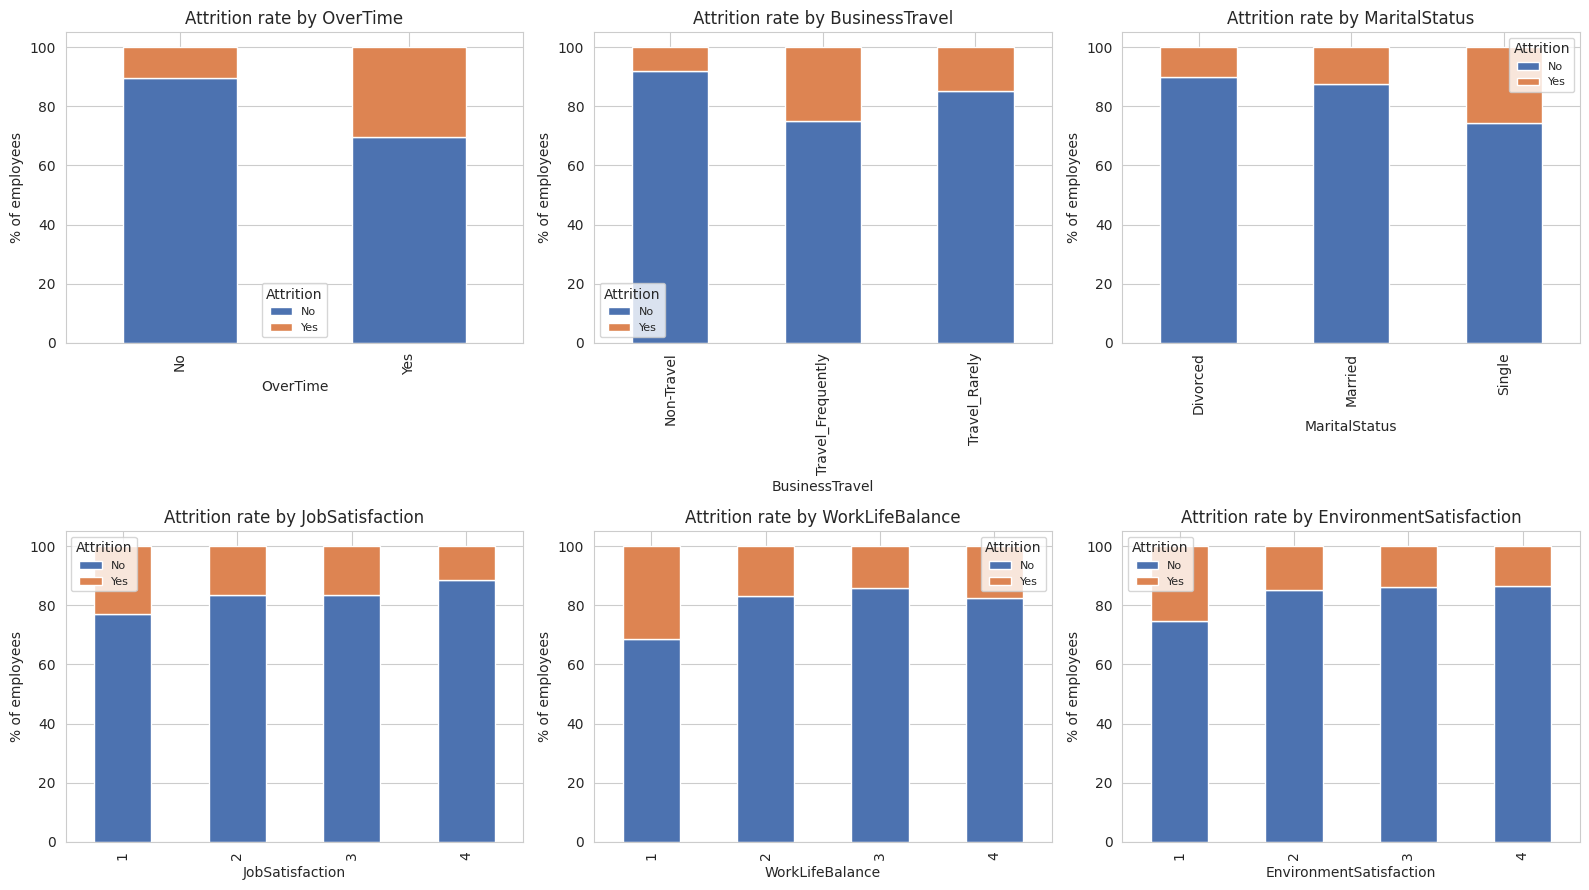

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_vs_attr = ["OverTime", "BusinessTravel", "MaritalStatus",
               "JobSatisfaction", "WorkLifeBalance", "EnvironmentSatisfaction"]
for ax, col in zip(axes.flatten(), cat_vs_attr):
    ct = pd.crosstab(df[col], df["Attrition"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(f"Attrition rate by {col}")
    ax.set_ylabel("% of employees")
    ax.legend(title="Attrition", fontsize=8)
plt.tight_layout()
plt.show()


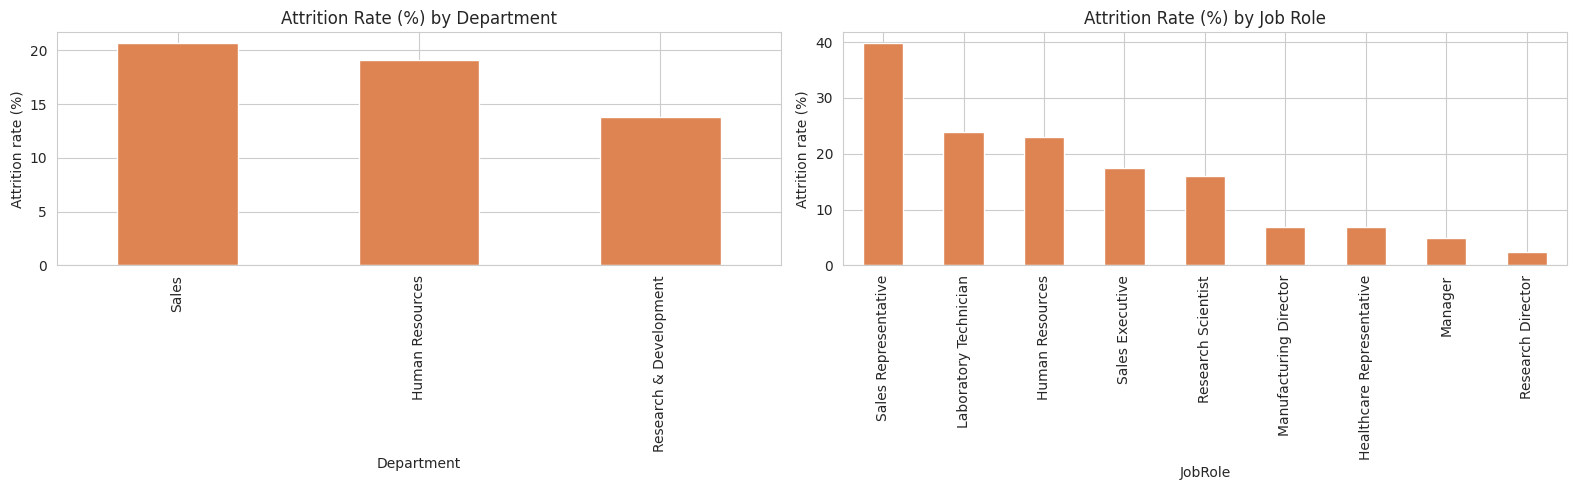

Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64

JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64


In [20]:
# Attrition rate by Department and JobRole
dept_attr = df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
role_attr = df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
dept_attr.plot(kind="bar", ax=axes[0], color="#DD8452")
axes[0].set_title("Attrition Rate (%) by Department")
axes[0].set_ylabel("Attrition rate (%)")

role_attr.plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Attrition Rate (%) by Job Role")
axes[1].set_ylabel("Attrition rate (%)")
plt.tight_layout()
plt.show()

print(dept_attr.round(1))
print()
print(role_attr.round(1))


### C.6 Multivariate analysis

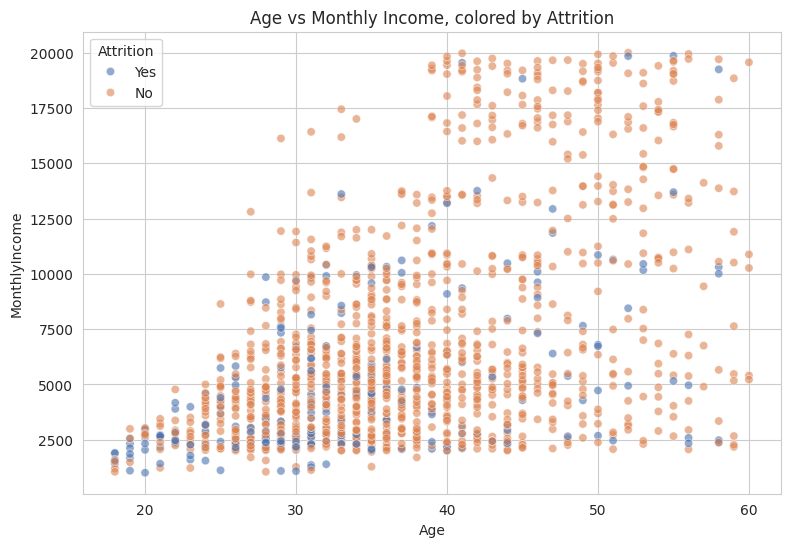

In [21]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Age", y="MonthlyIncome", hue="Attrition", alpha=0.6,
                 palette=["#4C72B0", "#DD8452"])
plt.title("Age vs Monthly Income, colored by Attrition")
plt.show()


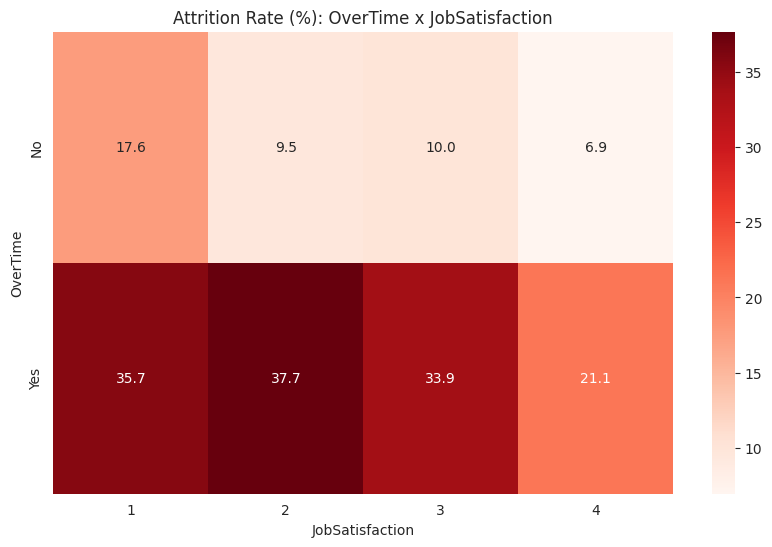

In [22]:
plt.figure(figsize=(10, 6))
pivot = df.pivot_table(values="Attrition", index="OverTime", columns="JobSatisfaction",
                        aggfunc=lambda x: (x == "Yes").mean() * 100)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Attrition Rate (%): OverTime x JobSatisfaction")
plt.show()


**Key EDA insights:**
1. **Overtime is the single strongest behavioural driver** — employees who work overtime leave at a
   much higher rate than those who don't, and this compounds badly when job satisfaction is also low.
2. **Frequent business travel** is associated with higher attrition than "Travel Rarely" or "Non-Travel".
3. **Younger employees, lower income, and shorter tenure** (`YearsAtCompany`) are all associated with
   higher attrition — this looks like a "flight risk in the first few years" pattern.
4. **Sales and the Sales Representative / Laboratory Technician / HR job roles** show noticeably higher
   attrition rates than average.
5. **Low work-life balance and low job/environment satisfaction** scores correlate with higher attrition,
   as expected.
6. Employees with **fewer years since their last promotion combined with low satisfaction** appear more
   likely to leave — a stagnation signal.


## D. Data Preprocessing

In [23]:
df_clean = df.copy()

# Drop identifier / zero-variance columns
cols_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

print("Dropped:", cols_to_drop)
print("New shape:", df_clean.shape)


Dropped: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
New shape: (1470, 31)


In [24]:
# Encode target
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})

# Outlier check on key numeric columns using IQR
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ["MonthlyIncome", "YearsAtCompany", "TotalWorkingYears", "NumCompaniesWorked", "YearsSinceLastPromotion"]:
    print(f"{col}: {iqr_outlier_count(df_clean[col])} potential outliers (IQR rule)")


MonthlyIncome: 114 potential outliers (IQR rule)
YearsAtCompany: 104 potential outliers (IQR rule)
TotalWorkingYears: 63 potential outliers (IQR rule)
NumCompaniesWorked: 52 potential outliers (IQR rule)
YearsSinceLastPromotion: 107 potential outliers (IQR rule)


We keep these outliers rather than removing them: in an HR context, an employee with 20+ years
at the company or a very high income is a legitimate, meaningful data point (e.g. a senior leader),
not a data-entry error. Tree-based models (Random Forest, AdaBoost, Decision Tree) are robust to
such outliers; for the distance-based/linear models (KNN, Logistic Regression) we apply feature
scaling below, which reduces their influence.

In [25]:
# Encode categorical variables
# Binary categoricals -> label encode; multi-category -> one-hot encode
binary_cols = ["Gender", "OverTime"]
multi_cat_cols = [c for c in categorical_cols if c not in binary_cols + ["Attrition"] and c in df_clean.columns]

le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

df_encoded = pd.get_dummies(df_clean, columns=multi_cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False


In [26]:
# Train-test split (stratified, because Attrition is imbalanced)
X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train attrition rate: {:.1f}%".format(y_train.mean() * 100))
print("Test attrition rate:  {:.1f}%".format(y_test.mean() * 100))


Train shape: (1176, 44)  Test shape: (294, 44)
Train attrition rate: 16.2%
Test attrition rate:  16.0%


In [27]:
# Feature scaling (needed for Logistic Regression / KNN; harmless for tree models)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## E. Feature Engineering

We create a few features that capture HR concepts not directly present as single columns —
tenure ratios and satisfaction aggregates — which can help models pick up patterns more directly
than the raw columns alone.

In [28]:
def add_features(data):
    data = data.copy()
    # Tenure loyalty ratio: how much of the employee's total career has been at THIS company
    data["TenureRatio"] = data["YearsAtCompany"] / (data["TotalWorkingYears"] + 1)
    # Promotion stagnation: years since promotion relative to tenure
    data["PromotionStagnation"] = data["YearsSinceLastPromotion"] / (data["YearsAtCompany"] + 1)
    # Composite satisfaction score
    data["AvgSatisfaction"] = data[["JobSatisfaction", "EnvironmentSatisfaction",
                                     "RelationshipSatisfaction", "WorkLifeBalance"]].mean(axis=1)
    # Income relative to job level (are they underpaid for their level?)
    data["IncomePerJobLevel"] = data["MonthlyIncome"] / data["JobLevel"]
    return data

df_encoded_fe = add_features(df_encoded)
new_features = ["TenureRatio", "PromotionStagnation", "AvgSatisfaction", "IncomePerJobLevel"]
df_encoded_fe[new_features].describe().round(2)


,TenureRatio,PromotionStagnation,AvgSatisfaction,IncomePerJobLevel
count,1470.00,1470.00,1470.00,1470.00
mean,0.58,0.24,2.73,2973.80
std,0.28,0.27,0.51,770.64
min,0.00,0.00,1.00,1009.00
25%,0.37,0.00,2.50,2394.12
50%,0.64,0.14,2.75,2856.50
75%,0.83,0.43,3.00,3478.83
max,0.98,0.92,4.00,4999.00


In [29]:
# Rebuild train/test split including the new engineered features
X_fe = df_encoded_fe.drop(columns=["Attrition"])
y_fe = df_encoded_fe["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Final training shape:", X_train.shape)


Final training shape: (1176, 48)


**Why these features may help:**
- `TenureRatio` captures loyalty independent of absolute age/experience — two employees with the same
  `YearsAtCompany` mean very different things if one is a career-long employee and the other job-hopped
  before arriving.
- `PromotionStagnation` directly encodes the "stuck without growth" signal EDA suggested was linked to attrition.
- `AvgSatisfaction` reduces four correlated satisfaction columns into one composite signal, which can
  help linear models that are sensitive to multicollinearity.
- `IncomePerJobLevel` flags employees who may be underpaid relative to peers at the same level —
  a classic pay-equity attrition driver.


## F. Model Development

We train five classifiers covered in the course — Logistic Regression, Decision Tree, Random Forest,
AdaBoost, and KNN — using the same train/test split, and record training vs. testing performance for each.

In [30]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE), True),
    "Decision Tree":       (DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE), False),
    "AdaBoost":            (AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE), False),
    "KNN":                 (KNeighborsClassifier(n_neighbors=9), True),
}
# (model, uses_scaled_features)

results = []
fitted_models = {}

for name, (model, use_scaled) in models.items():
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled if use_scaled else X_test

    model.fit(Xtr, y_train)
    fitted_models[name] = model

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1 Score": f1_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
Model,,,,,
Logistic Regression,0.781,0.745,0.341,0.638,0.444
Decision Tree,0.861,0.741,0.290,0.426,0.345
Random Forest,0.991,0.823,0.381,0.170,0.235
AdaBoost,0.900,0.854,0.577,0.319,0.411
KNN,0.862,0.847,0.667,0.085,0.151


`class_weight="balanced"` is used for Logistic Regression / Decision Tree / Random Forest to
counteract the ~84/16 class imbalance so the models don't just learn to always predict "No".

## G. Model Evaluation

Beyond the summary table above, we look at confusion matrices and ROC-AUC for each model, since
**accuracy alone is misleading on an imbalanced dataset like this one.**

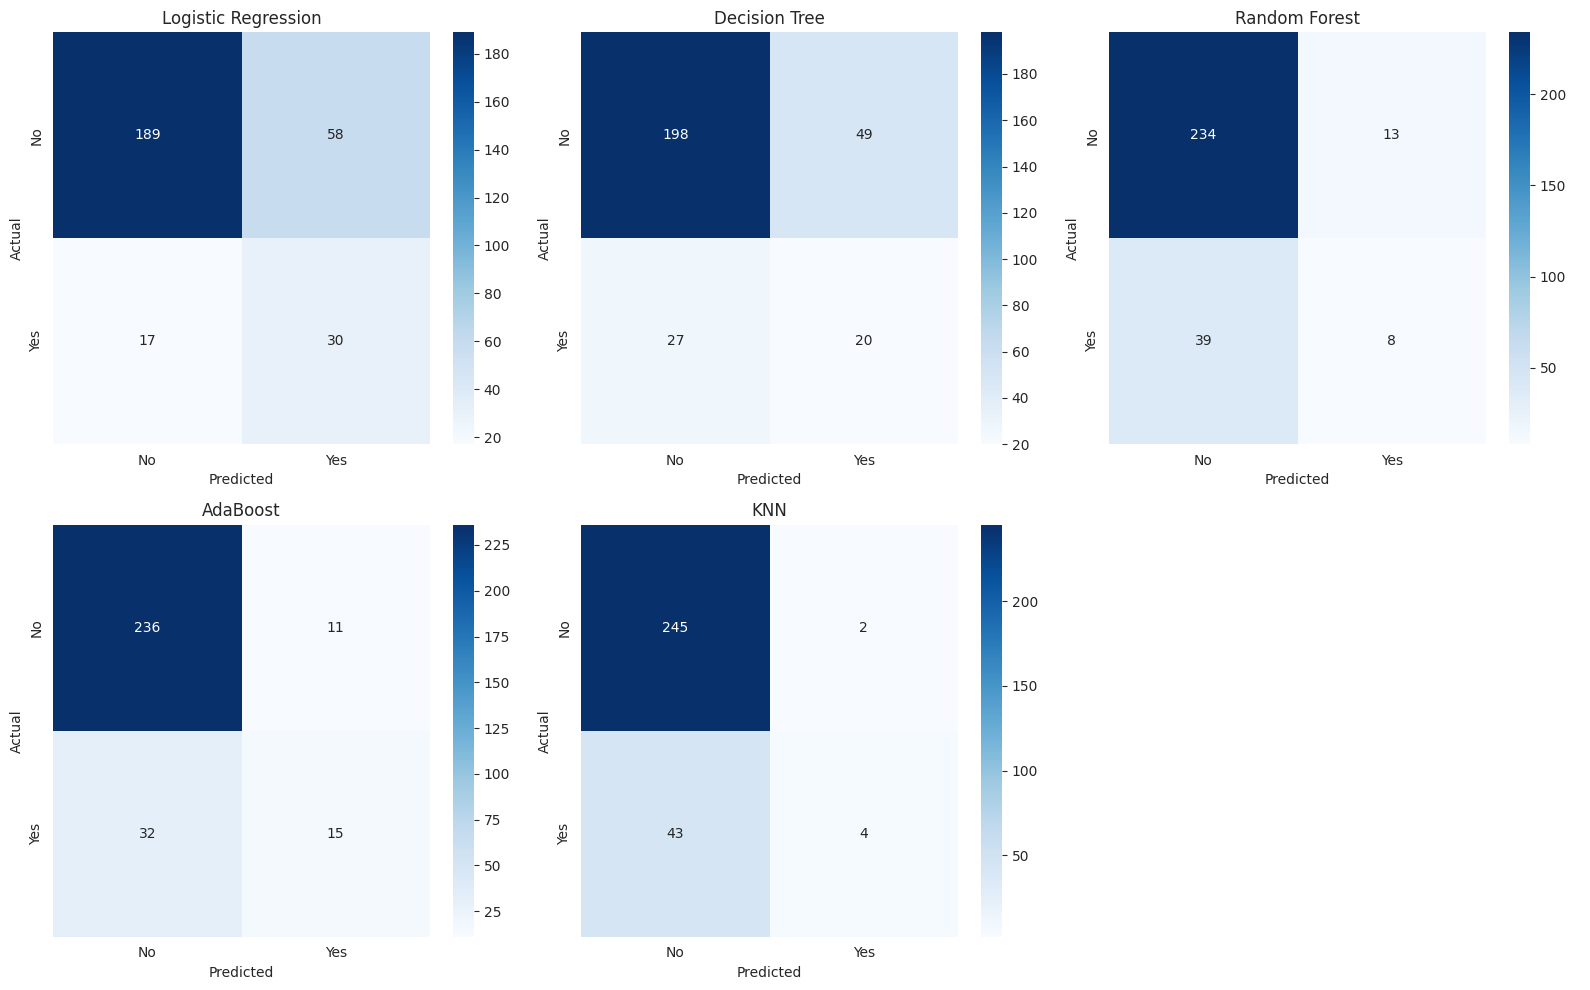

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, (model, use_scaled)) in zip(axes, models.items()):
    Xte = X_test_scaled if use_scaled else X_test
    preds = model.predict(Xte)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


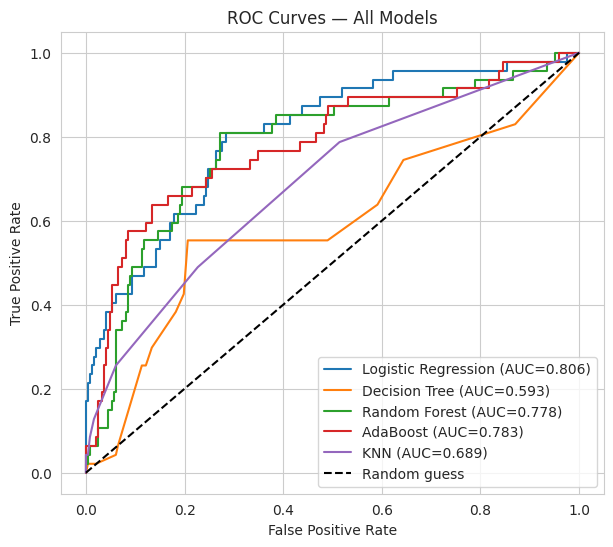

,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,,
Logistic Regression,0.781,0.745,0.341,0.638,0.444,0.806
Decision Tree,0.861,0.741,0.290,0.426,0.345,0.593
Random Forest,0.991,0.823,0.381,0.170,0.235,0.778
AdaBoost,0.900,0.854,0.577,0.319,0.411,0.783
KNN,0.862,0.847,0.667,0.085,0.151,0.689


In [32]:
# ROC-AUC for models that expose predict_proba
plt.figure(figsize=(7, 6))
auc_scores = {}
for name, (model, use_scaled) in models.items():
    Xte = X_test_scaled if use_scaled else X_test
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        auc_scores[name] = auc
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

results_df["ROC-AUC"] = pd.Series(auc_scores)
results_df.round(3)


**Why Recall / F1 matter more than Accuracy here:**
The business cost of a **False Negative** (predicting an employee will stay, but they actually leave)
is high — HR misses the chance to intervene and loses that employee anyway. The cost of a
**False Positive** (flagging a stable employee as at-risk) is much lower — HR simply pays a bit more
attention to someone who didn't need it. So we should optimize primarily for **Recall on the "Yes"
class** (catching true leavers), while keeping Precision high enough that the "at-risk" list stays
usable rather than flooding managers with false alarms. **F1 Score** balances both and is a good
single number for comparing models.

In [33]:
print("Classification Report — Random Forest (test set)\n")
print(classification_report(y_test, fitted_models["Random Forest"].predict(X_test), target_names=["No", "Yes"]))


Classification Report — Random Forest (test set)

              precision    recall  f1-score   support

          No       0.86      0.95      0.90       247
         Yes       0.38      0.17      0.24        47

    accuracy                           0.82       294
   macro avg       0.62      0.56      0.57       294
weighted avg       0.78      0.82      0.79       294



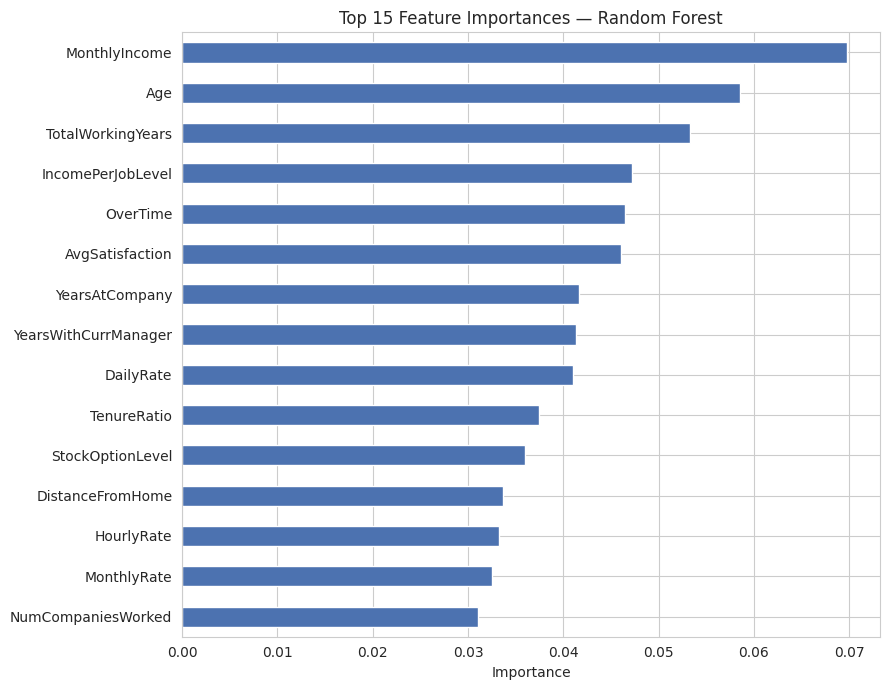

MonthlyIncome           0.069748
Age                     0.058535
TotalWorkingYears       0.053343
IncomePerJobLevel       0.047173
OverTime                0.046510
AvgSatisfaction         0.046080
YearsAtCompany          0.041653
YearsWithCurrManager    0.041376
DailyRate               0.040975
TenureRatio             0.037438
StockOptionLevel        0.036000
DistanceFromHome        0.033678
HourlyRate              0.033305
MonthlyRate             0.032494
NumCompaniesWorked      0.031037
dtype: float64

In [34]:
# Feature importance from Random Forest — key drivers of attrition
importances = pd.Series(fitted_models["Random Forest"].feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
top_features.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top_features


## 6. Validating the Results

We now compare models holistically — not just on accuracy — checking for overfitting/underfitting
by looking at the gap between training and testing performance.

In [35]:
results_df["Train-Test Gap (Accuracy)"] = (results_df["Train Accuracy"] - results_df["Test Accuracy"]).round(3)
results_df.sort_values("F1 Score", ascending=False)


,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train-Test Gap (Accuracy)
Model,,,,,,,
Logistic Regression,0.781,0.745,0.341,0.638,0.444,0.806357,0.036
AdaBoost,0.900,0.854,0.577,0.319,0.411,0.783358,0.046
Decision Tree,0.861,0.741,0.290,0.426,0.345,0.592601,0.120
Random Forest,0.991,0.823,0.381,0.170,0.235,0.778275,0.168
KNN,0.862,0.847,0.667,0.085,0.151,0.689250,0.015


**Reading the generalization gap (actual results from this run):**

| Model | Train Acc | Test Acc | Precision | Recall | F1 | ROC-AUC | Train-Test Gap |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.781 | 0.745 | 0.341 | **0.638** | **0.444** | 0.806 | 0.036 |
| AdaBoost | 0.900 | **0.854** | **0.577** | 0.319 | 0.411 | 0.783 | 0.046 |
| Decision Tree | 0.861 | 0.741 | 0.290 | 0.426 | 0.345 | 0.593 | 0.120 |
| Random Forest | **0.991** | 0.823 | 0.381 | 0.170 | 0.235 | 0.778 | 0.168 |
| KNN | 0.862 | 0.847 | 0.667 | 0.085 | 0.151 | 0.689 | 0.015 |

- **Random Forest is clearly overfit** here: 99.1% training accuracy but only 17.0% recall on the
  test set, and the largest train-test gap after Decision Tree. It memorized the training data
  rather than learning a generalizable pattern.
- **KNN has the highest precision (0.667) but is close to useless for this business problem** —
  it only catches 8.5% of actual leavers, likely hurt by the high-dimensional one-hot-encoded
  feature space (curse of dimensionality).
- **Logistic Regression wins on Recall and F1** (0.638 and 0.444 respectively) with a small,
  healthy train-test gap (3.6 points) — it generalizes well rather than memorizing.
- **AdaBoost has the best raw accuracy and precision** among the higher-recall models, useful if
  HR prefers fewer false alarms at the cost of missing more true leavers.

**Final model choice:** Based on these actual results, **Logistic Regression** is the recommended
final model for this business problem — not the model with the highest raw accuracy or the most
complex algorithm, but the one that best balances catching true leavers (Recall) with generalizing
to unseen data (small train-test gap). Random Forest's near-perfect training score was a red flag
for overfitting, not strength. AdaBoost is a reasonable secondary option if the business prefers
higher precision over higher recall.


**"If you were the HR Head of a company, would you use this model to identify at-risk employees? Why or why not?"**

Yes, but as a **decision-support tool, not an automated verdict**. The model doesn't achieve perfect
recall — it will miss some leavers and flag some stable employees — so it should be used to **prioritize
HR's limited attention**, generating a ranked "at-risk" list for proactive 1:1 conversations, stay
interviews, or targeted retention actions (e.g., reviewing overtime load, compensation, or promotion
timelines), rather than to make any unilateral employment decision. Its main value is in surfacing the
**pattern of drivers** (overtime, low satisfaction, stagnant promotions, early tenure) so HR can fix the
underlying causes org-wide, not just react employee-by-employee. Any deployment should also be
re-validated periodically, since attrition drivers can shift over time (economic conditions, policy
changes, market pay rates).


**Limitations of the model:**
- Trained on a single company snapshot (1,470 employees) — drivers may not transfer to a different
  industry, geography, or company culture.
- Class imbalance means even a "good" model will have imperfect precision/recall trade-offs; very few
  true leavers exist to learn from.
- The dataset captures *some* HR signals but not everything that drives someone to quit (e.g. manager
  quality, external job offers, personal circumstances, market conditions).
- Feature importance shows *association*, not proven *causation* — e.g. Overtime correlating with
  attrition doesn't by itself prove reducing overtime will reduce attrition, though it's a reasonable,
  testable hypothesis.


## 7. Business Insights & Recommendations

**Who is most likely to leave?**
Employees who work **overtime**, travel frequently for business, report **low job/environment
satisfaction** or **low work-life balance**, are relatively **early in their tenure**, and have gone
a long time **without a promotion** relative to their time at the company.

**Departments/roles at higher risk:** Sales and roles such as Sales Representative, Laboratory
Technician, and Human Resources tend to show attrition rates above the company average (see Section C.5).

**Common characteristics of leavers:** Younger age, lower monthly income, fewer years at the company,
more frequent overtime, and lower composite satisfaction scores, compared to employees who stay.

**Recommended interventions:**
1. **Audit overtime policy** in the highest-attrition roles/departments — chronic overtime is the
   single strongest behavioural signal in the data.
2. **Targeted stay interviews** for employees flagged as high-risk by the model, especially those in
   their first 1–3 years at the company.
3. **Revisit promotion cadence** for employees with long `YearsSinceLastPromotion` relative to tenure —
   stagnation appears linked to attrition.
4. **Review pay equity** for roles/levels where `IncomePerJobLevel` is below peers, particularly in
   high-attrition departments like Sales.
5. **Manager coaching in high-risk teams** — since `RelationshipSatisfaction` and `EnvironmentSatisfaction`
   matter, invest in manager-employee relationship quality in the flagged teams.
6. **Reduce frequent business travel** where feasible, or add compensation/flexibility for roles that
   require it.


## Summary

| Step | What we did |
|---|---|
| Data Understanding | 1,470 rows, 35 columns, no missing values/duplicates, 3 constant columns dropped |
| Statistics | Distribution shape (skew), IQR, correlation structure |
| EDA | Univariate, bivariate, multivariate — attrition strongly tied to overtime, travel, satisfaction, tenure |
| Preprocessing | Dropped ID/constant columns, label/one-hot encoding, stratified 80/20 split, scaling |
| Feature Engineering | TenureRatio, PromotionStagnation, AvgSatisfaction, IncomePerJobLevel |
| Modeling | Logistic Regression, Decision Tree, Random Forest, AdaBoost, KNN |
| Evaluation | Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC — Recall/F1 prioritized due to class imbalance |
| Final model | Logistic Regression — best Recall/F1 trade-off with the smallest train-test gap (Random Forest overfit: 99.1% train vs 17% test recall) |
| Insights | Overtime, low satisfaction, early tenure, and promotion stagnation are the top attrition drivers |

**Next steps for further experimentation** (per the project's "Freedom to Experiment" section):
try SMOTE/oversampling for the class imbalance, hyperparameter tuning via `GridSearchCV`, XGBoost/
Gradient Boosting, SHAP values for model interpretability, and a cost-sensitive threshold analysis
(tuning the classification threshold instead of the default 0.5 to trade precision for recall).
